<a href="https://colab.research.google.com/github/lunamonnlight/PF_169493/blob/main/lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eksploracyjna analiza tekstu (EDA)


W tym notatniku przećwiczymy kluczowe etapy eksploracyjnej analizy tekstu:

1. Ładowanie i wstępny przegląd danych
2. Tokenizacja i obliczanie statystyk korpusu
3. Rozkład długości dokumentów
4. Type–Token Ratio (TTR)
5. Hapax legomena
6. Najczęstsze słowa (z i bez stop words)
7. Statystyki na poziomie dokumentu
8. Wizualizacja: chmury słów
9. Wizualizacja: histogramy częstości
10. N-gramy (bigramy i trigramy)
11. Prawo Zipfa

Do ćwiczeń wykorzystamy kilka zbiorów danych w języku polskim (pliki CSV).

---
## 0. Instalacja i import bibliotek

Zainstaluj wymagane pakiety (na Colabie wystarczy uruchomić poniższą komórkę).

In [1]:
!pip install nltk wordcloud matplotlib pandas --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize
from nltk import ngrams
from wordcloud import WordCloud

# Polskie stop words — pobieramy z internetu
import urllib.request
url = "https://raw.githubusercontent.com/bieli/stopwords/master/polish.stopwords.txt"
response = urllib.request.urlopen(url)
stop_pl = set(response.read().decode("utf-8").splitlines())

print("Wszystko gotowe!")
print(f"Załadowano {len(stop_pl)} polskich stop words.")

Wszystko gotowe!
Załadowano 350 polskich stop words.


---
## 1. Ładowanie danych

Wgraj pliki CSV do Colaba (ikona folderu po lewej → Upload) lub użyj poniższego kodu do wgrania plików.

Dostępne zbiory danych:
- **`recenzje_filmowe.csv`** — recenzje filmów z etykietami sentymentu (pozytywna/negatywna)
- **`opinie_produktowe.csv`** — opinie o produktach ze sklepu internetowego (kategoria + ocena)
- **`recenzje_restauracji.csv`** — opinie o restauracjach (nazwa + ocena)

**Zadanie:** Załaduj wybrany zbiór danych do DataFrame i wyświetl kilka pierwszych wierszy. Sprawdź kolumny, rozmiar i typy danych.

In [8]:
# Załaduj wybrany plik CSV
# Ponieważ plik jest już dostępny w sesji, wczytujemy go bezpośrednio
df = pd.read_csv("recenzje_restauracji.csv")

# Wyświetl kilka pierwszych wierszy
display(df.head())

,text,restauracja,ocena
0,Najlepsza pizza w mieście! Ciasto cienkie i ch...,Pizzeria Napoli,5
1,Zupa dnia była letnia i bez smaku. Drugie dani...,Bistro Pod Lipą,1
2,Fantastyczne sushi za rozsądną cenę. Ryba świe...,Sakura Sushi Bar,5
3,Obiad dnia za trzydzieści złotych to żart. Por...,Gospoda Staropolska,1
4,"Pierogi ruskie jak u babci. Ciasto miękkie, fa...",Pierogarnia Mąka,5


In [9]:
# Wyświetl podstawowe informacje o zbiorze:
print(f"Rozmiar ramki danych: {df.shape}")
print("\nKolumny:")
print(df.columns)
print("\nTypy danych:")
print(df.dtypes)

print("\nPierwsze 3 teksty recenzji:")
display(df["text"].head(3))

Rozmiar ramki danych: (20, 3)

Kolumny:
Index(['text', 'restauracja', 'ocena'], dtype='object')

Typy danych:
text           object
restauracja    object
ocena           int64
dtype: object

Pierwsze 3 teksty recenzji:


,text
0,Najlepsza pizza w mieście! Ciasto cienkie i ch...
1,Zupa dnia była letnia i bez smaku. Drugie dani...
2,Fantastyczne sushi za rozsądną cenę. Ryba świe...


---
## 2. Tokenizacja i podstawowe statystyki korpusu

Pierwszym krokiem EDA jest obliczenie **podstawowych metryk**:

| Metryka | Opis |
|---|---|
| Liczba dokumentów | Ile tekstów zawiera korpus |
| Łączna liczba tokenów | Suma tokenów we wszystkich dokumentach |
| Liczba unikalnych tokenów (typy) | Rozmiar słownika |
| Średnia długość dokumentu | Przeciętna liczba tokenów na dokument |
| Mediana długości | Odporniejsza na wartości odstające niż średnia |
| Min / Max długości | Rozpiętość |

**Zadanie:** Stokenizuj kolumnę `text` za pomocą `word_tokenize` (z parametrem `language="polish"`). Oblicz i wyświetl powyższe metryki.

In [12]:
# Tokenizacja
df['tokens'] = df['text'].apply(lambda x: word_tokenize(x, language='polish'))
df['n_tokens'] = df['tokens'].apply(len)

# Obliczanie metryk
all_tokens_list = [t for sublist in df['tokens'] for t in sublist]
unique_tokens = len(set(all_tokens_list))

stats = {
    'Liczba dokumentów': len(df),
    'Łączna liczba tokenów': df['n_tokens'].sum(),
    'Liczba unikalnych tokenów (typy)': unique_tokens,
    'Średnia długość dokumentu': df['n_tokens'].mean(),
    'Mediana długości': df['n_tokens'].median(),
    'Min długości': df['n_tokens'].min(),
    'Max długości': df['n_tokens'].max()
}

# Wyświetlenie wyników w czytelnej formie
for metric, value in stats.items():
    print(f"{metric:35}: {value}")

Liczba dokumentów                  : 20
Łączna liczba tokenów              : 438
Liczba unikalnych tokenów (typy)   : 283
Średnia długość dokumentu          : 21.9
Mediana długości                   : 22.0
Min długości                       : 18
Max długości                       : 27


---
## 3. Rozkład długości dokumentów

Histogram długości dokumentów pozwala szybko ocenić **strukturę korpusu**.

Na co zwracać uwagę:
- **Skośność** — czy rozkład jest silnie prawostronny? (typowe dla tekstu)
- **Wartości odstające** — bardzo krótkie / bardzo długie dokumenty mogą wymagać filtrowania
- **Multimodalność** — dwa szczyty mogą sugerować dwa różne typy dokumentów

**Zadanie:** Narysuj histogram długości dokumentów (w tokenach). Dodaj linię mediany.

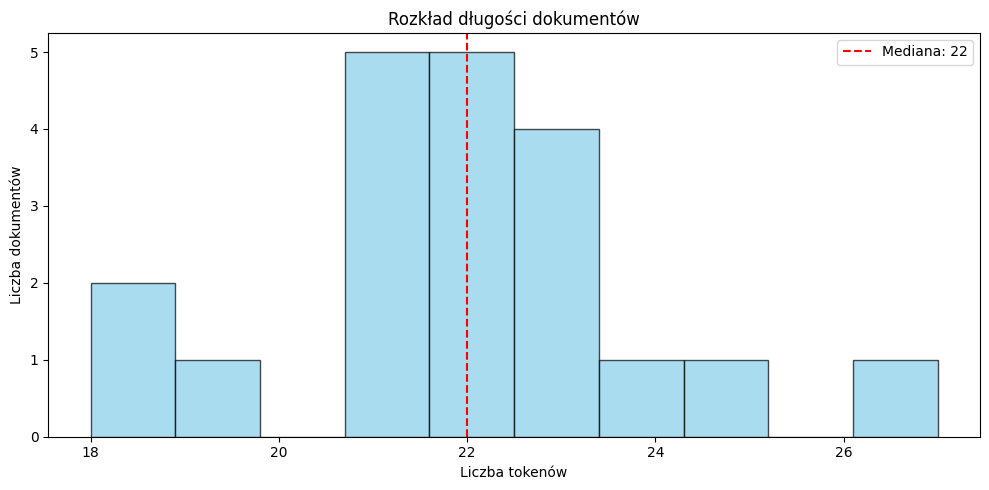

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df["n_tokens"], bins=10, edgecolor="black", alpha=0.7, color="skyblue")
plt.xlabel("Liczba tokenów")
plt.ylabel("Liczba dokumentów")
plt.title("Rozkład długości dokumentów")

median_val = df["n_tokens"].median()
plt.axvline(median_val, color="red", linestyle="--", label=f"Mediana: {median_val:.0f}")

plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Type–Token Ratio (TTR)

**TTR** = liczba unikalnych tokenów / łączna liczba tokenów

Mierzy **zróżnicowanie leksykalne** tekstu:
- TTR bliskie **1** → bogaty, różnorodny język (np. proza literacka)
- TTR bliskie **0** → powtarzalne, ograniczone słownictwo (np. instrukcje techniczne)

**Uwaga:** TTR zależy silnie od długości tekstu — dłuższe teksty mają niższy TTR.

**Zadanie:**
1. Zbierz wszystkie tokeny z korpusu w jedną listę.
2. Odfiltruj interpunkcję (zostaw tylko tokeny `isalpha()` i dłuższe niż 1 znak).
3. Znormalizuj do lowercase.
4. Oblicz TTR dla całego korpusu.

In [16]:
# Zbierz wszystkie tokeny
all_tokens = [t for sublist in df['tokens'] for t in sublist]

# Filtrowanie i normalizacja
# Zostawiamy tylko znaki alfabetyczne i słowa dłuższe niż 1 znak
word_tokens = [t.lower() for t in all_tokens if t.isalpha() and len(t) > 1]

# Oblicz TTR
types = set(word_tokens)
ttr = len(types) / len(word_tokens) if len(word_tokens) > 0 else 0

print(f"Łączna liczba słów (po filtrowaniu): {len(word_tokens)}")
print(f"Liczba unikalnych słów (typy): {len(types)}")
print(f"Współczynnik TTR dla korpusu: {ttr:.4f}")

Łączna liczba słów (po filtrowaniu): 322
Liczba unikalnych słów (typy): 261
Współczynnik TTR dla korpusu: 0.8106


---
## 5. Hapax legomena

**Hapax legomenon** (gr. *raz powiedziane*) — słowo występujące w korpusie **dokładnie raz**.

Dlaczego to istotne:
- Hapax legomena stanowią zwykle **40–60% słownika**, ale ułamek procenta tokenów
- Są to często literówki, nazwiska, neologizmy, słowa specjalistyczne
- Pomagają ocenić **szum** w danych

**Zadanie:** Użyj `Counter` na liście `word_tokens` i znajdź słowa występujące dokładnie raz. Ile jest hapax legomena? Jaki procent słownika stanowią? Wyświetl kilka przykładów.

In [17]:
# Używamy Counter do zliczenia częstości
freq = Counter(word_tokens)

# Znajdujemy hapaxy (występujące tylko raz)
hapax = [w for w, c in freq.items() if c == 1]

# Statystyki
n_hapax = len(hapax)
pct_vocabulary = (n_hapax / len(types)) * 100 if len(types) > 0 else 0

print(f"Liczba hapax legomena: {n_hapax}")
print(f"Procent słownika: {pct_vocabulary:.2f}%")
print("\nPrzykładowe hapaxy:")
print(hapax[:15])

Liczba hapax legomena: 229
Procent słownika: 87.74%

Przykładowe hapaxy:
['pizza', 'mieście', 'cienkie', 'chrupiące', 'składniki', 'sos', 'pomidorowy', 'domowej', 'roboty', 'miła', 'szybka', 'pewno', 'wrócę', 'zupa', 'była']


---
## 6. Najczęstsze słowa

Lista najczęstszych słów pozwala szybko ocenić **charakter korpusu**.

Typowe obserwacje:
- Na szczycie są **stop words**: „i", „w", „na", „z", „nie", „to", „się"
- Po usunięciu stop words pojawiają się słowa **dziedzinowe** — to wartościowa informacja

**Zadanie:**
1. Wyświetl top 20 najczęstszych słów **ze** stop words (z prostym wykresem słupkowym w terminalu).
2. Stwórz nowy `Counter` **bez** stop words i wyświetl top 20.

In [18]:
# Top 20 ze stop words
top_with_stop = freq.most_common(20)
print("Top 20 słów (ze stop words):")
for word, count in top_with_stop:
    print(f"{word:15} | {count}")

Top 20 słów (ze stop words):
na              | 7
za              | 7
jak             | 7
złotych         | 5
to              | 5
nie             | 4
porcje          | 4
do              | 4
ciasto          | 3
świeże          | 3
najlepsza       | 2
obsługa         | 2
dnia            | 2
bez             | 2
smaku           | 2
przyszło        | 2
po              | 2
kelner          | 2
proszku         | 2
tego            | 2


In [19]:
# Top 20 BEZ stop words
word_tokens_no_stop = [w for w in word_tokens if w not in stop_pl]
freq_no_stop = Counter(word_tokens_no_stop)

top_no_stop = freq_no_stop.most_common(20)
print("Top 20 słów (BEZ stop words):")
for word, count in top_no_stop:
    print(f"{word:15} | {count}")

Top 20 słów (BEZ stop words):
złotych         | 5
porcje          | 4
ciasto          | 3
świeże          | 3
najlepsza       | 2
obsługa         | 2
dnia            | 2
smaku           | 2
przyszło        | 2
kelner          | 2
proszku         | 2
dwadzieścia     | 2
mięso           | 2
frytki          | 2
kawa            | 2
godziny         | 2
kuchnia         | 2
ceny            | 2
jedzenie        | 2
pyszne          | 2


---
## 7. Statystyki na poziomie dokumentu

Warto badać nie tylko cały korpus, ale także **rozkłady wewnątrz dokumentów**:

- **TTR per dokument** — zróżnicowanie leksykalne każdego tekstu
- **Średnia długość słowa** — krótsze słowa mogą sugerować prostszy język
- **Udział stop words** — jaki procent tokenów to słowa funkcyjne

Takie metryki mogą służyć jako **cechy (features)** w klasyfikacji dokumentów.

**Zadanie:** Dla każdego dokumentu oblicz TTR, średnią długość słowa i udział stop words. Wyświetl statystyki opisowe (`describe()`).

In [20]:
# Funkcja pomocnicza do czyszczenia tokenów (tylko alfabetyczne)
def get_clean_tokens(tokens):
    return [t.lower() for t in tokens if t.isalpha()]

# Obliczanie metryk dla każdego dokumentu
df['clean_tokens'] = df['tokens'].apply(get_clean_tokens)

# 1. TTR per dokument
df['ttr'] = df['clean_tokens'].apply(lambda t: len(set(t)) / len(t) if len(t) > 0 else 0)

# 2. Średnia długość słowa
df['avg_word_len'] = df['clean_tokens'].apply(lambda t: np.mean([len(w) for w in t]) if len(t) > 0 else 0)

# 3. Udział stop words (w stosunku do wszystkich tokenów)
df['stop_ratio'] = df['tokens'].apply(lambda t: len([w for w in t if w.lower() in stop_pl]) / len(t) if len(t) > 0 else 0)

# Wyświetlenie statystyk opisowych
print("Statystyki opisowe cech dokumentów:")
display(df[['n_tokens', 'ttr', 'avg_word_len', 'stop_ratio']].describe())

Statystyki opisowe cech dokumentów:


,n_tokens,ttr,avg_word_len,stop_ratio
count,20.000000,20.000000,20.000000,20.000000
mean,21.900000,0.980935,5.747551,0.222637
std,2.149663,0.031422,0.521000,0.059422
min,18.000000,0.900000,4.789474,0.111111
25%,21.000000,0.951128,5.408824,0.173913
50%,22.000000,1.000000,5.638889,0.227273
75%,23.000000,1.000000,6.097689,0.274545
max,27.000000,1.000000,6.666667,0.304348


---
## 8. Wizualizacja: chmury słów

Chmura słów to popularna (choć uproszczona) metoda wizualizacji częstości:
- Rozmiar słowa ∝ jego częstość
- **Ograniczenia:** brak precyzji, trudność porównywania

Ciekawsza technika: **chmury porównawcze** między kategoriami (np. recenzje pozytywne vs. negatywne).

**Zadanie:**
1. Wygeneruj chmurę słów dla całego korpusu (z `stopwords=stop_pl`).
2. *(Dla zbiorów z etykietami)* Wygeneruj osobne chmury dla różnych kategorii.

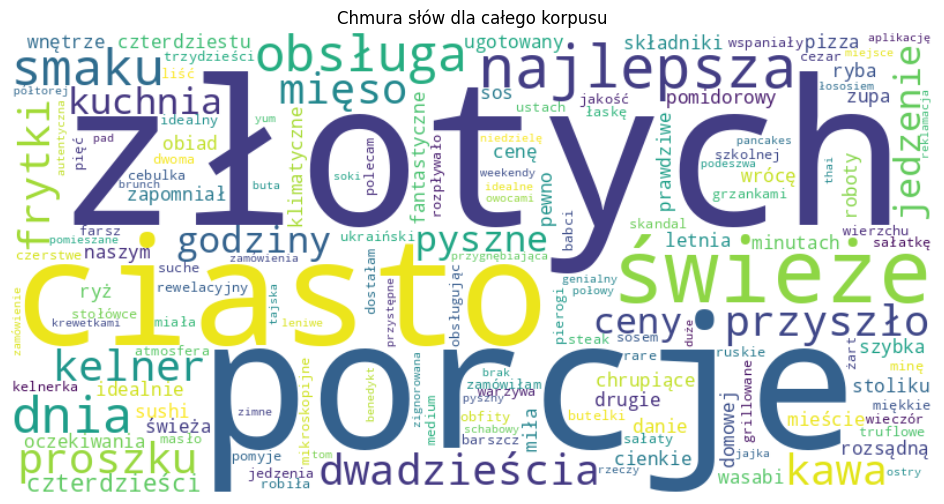

In [21]:
# Chmura słów dla całego korpusu
text_all = " ".join(word_tokens)
wc = WordCloud(width=800, height=400,
               background_color="white",
               max_words=150,
               colormap="viridis",
               stopwords=stop_pl)
wc.generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Chmura słów dla całego korpusu")
plt.show()

In [ ]:
# Chmury porównawcze (np. pozytywne vs. negatywne recenzje)
# Wskazówka: odfiltruj df po kolumnie etykiety,
# zbierz tokeny osobno dla każdej grupy,
# narysuj dwie chmury obok siebie (fig, axes = plt.subplots(1, 2, ...))



---
## 9. Wizualizacja: histogramy częstości

Wykres słupkowy top-N słów jest bardziej **precyzyjny** niż chmura.

**Zadanie:** Narysuj poziomy wykres słupkowy (`barh`) z 25 najczęstszymi słowami (bez stop words).

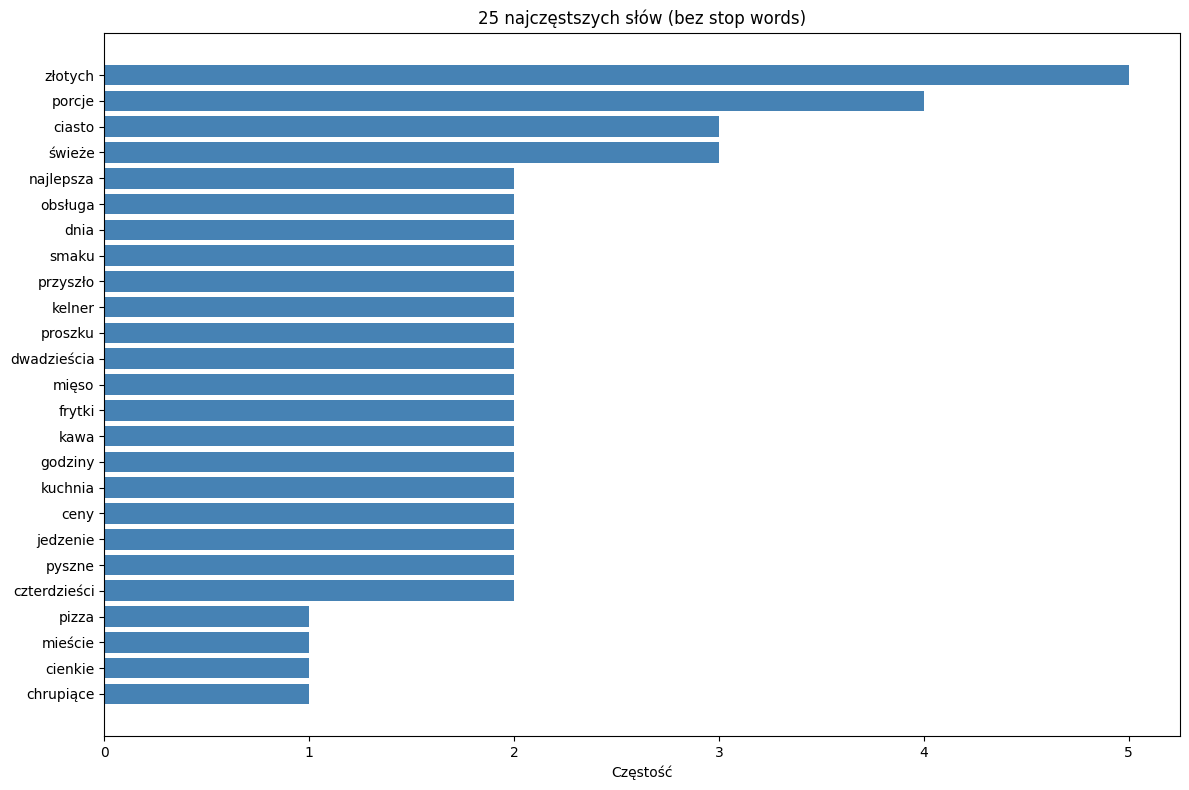

In [22]:
# Pobranie top 25 słów
top_words = freq_no_stop.most_common(25)
words, counts = zip(*top_words)

# Tworzenie wykresu
plt.figure(figsize=(12, 8))
plt.barh(range(len(words)), counts, color="steelblue")
plt.yticks(range(len(words)), words)
plt.xlabel("Częstość")
plt.title("25 najczęstszych słów (bez stop words)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 10. N-gramy

Analiza pojedynczych słów (unigramów) nie chwyta **fraz** i **kolokacji**.

**N-gram** — ciąg n kolejnych tokenów:
- **Bigram:** „nie lubię", „bardzo dobry", „efekty specjalne"
- **Trigram:** „nie do końca", „na pewno nie", „jeden z najlepszych"

**Zadanie:**
1. Wygeneruj bigramy z `word_tokens` (użyj `nltk.ngrams`).
2. Wyświetl top 15 bigramów.
3. Odfiltruj bigramy zawierające stop words i wyświetl top 15 ponownie.
4. *(Opcjonalnie)* Zrób to samo dla trigramów.

In [23]:
# Bigramy — wszystkie
all_bigrams = list(ngrams(word_tokens, 2))
bigram_freq = Counter(all_bigrams)

print("Top 15 bigramów (wszystkie):")
for bg, count in bigram_freq.most_common(15):
    print(f"{' '.join(bg):25} | {count}")

Top 15 bigramów (wszystkie):
bez smaku                 | 2
przyszło po               | 2
złotych to                | 2
do tego                   | 2
za dwadzieścia            | 2
najlepsza pizza           | 1
pizza mieście             | 1
mieście ciasto            | 1
ciasto cienkie            | 1
cienkie chrupiące         | 1
chrupiące składniki       | 1
składniki świeże          | 1
świeże sos                | 1
sos pomidorowy            | 1
pomidorowy domowej        | 1


In [24]:
# Bigramy — bez stop words (usuwamy te, gdzie choć jedno słowo jest stop wordem)
bigrams_filtered = [(a, b) for a, b in all_bigrams if a not in stop_pl and b not in stop_pl]
bigram_freq_f = Counter(bigrams_filtered)

print("Top 15 bigramów (bez stop words):")
for bg, count in bigram_freq_f.most_common(15):
    print(f"{' '.join(bg):25} | {count}")

Top 15 bigramów (bez stop words):
najlepsza pizza           | 1
pizza mieście             | 1
mieście ciasto            | 1
ciasto cienkie            | 1
cienkie chrupiące         | 1
chrupiące składniki       | 1
składniki świeże          | 1
świeże sos                | 1
sos pomidorowy            | 1
pomidorowy domowej        | 1
domowej roboty            | 1
roboty obsługa            | 1
obsługa miła              | 1
miła szybka               | 1
pewno wrócę               | 1


In [25]:
# Trigramy — bez stop words
all_trigrams = list(ngrams(word_tokens, 3))
trigrams_filtered = [(a, b, c) for a, b, c in all_trigrams if a not in stop_pl and b not in stop_pl and c not in stop_pl]
trigram_freq_f = Counter(trigrams_filtered)

print("Top 10 trigramów (bez stop words):")
for tg, count in trigram_freq_f.most_common(10):
    print(f"{' '.join(tg):30} | {count}")

Top 10 trigramów (bez stop words):
najlepsza pizza mieście        | 1
pizza mieście ciasto           | 1
mieście ciasto cienkie         | 1
ciasto cienkie chrupiące       | 1
cienkie chrupiące składniki    | 1
chrupiące składniki świeże     | 1
składniki świeże sos           | 1
świeże sos pomidorowy          | 1
sos pomidorowy domowej         | 1
pomidorowy domowej roboty      | 1


---
## 11. Prawo Zipfa

**George Kingsley Zipf** (1935) zauważył regularność: jeśli posortujemy słowa od najczęstszego do najrzadszego i przypiszemy im **rangi** (1, 2, 3, …), to:

$$f(r) \approx \frac{C}{r^\alpha}$$

gdzie f(r) to częstość słowa o randze r, C to stała, α ≈ 1.

Inaczej: **ranga × częstość ≈ const**.

Konsekwencje:
- Nieliczne słowa dominują — 100 najczęstszych słów pokrywa zwykle 50%+ tekstu
- Ogon rozkładu jest długi — tysiące słów pojawiają się 1–2 razy

**Zadanie:**
1. Posortuj częstości malejąco i przypisz rangi.
2. Narysuj wykres **log-log** (ranga vs. częstość).
3. Dodaj linię teoretyczną Zipfa (α=1).
4. Oblicz, jaki procent wszystkich tokenów pokrywają top-100 i top-1000 słów.

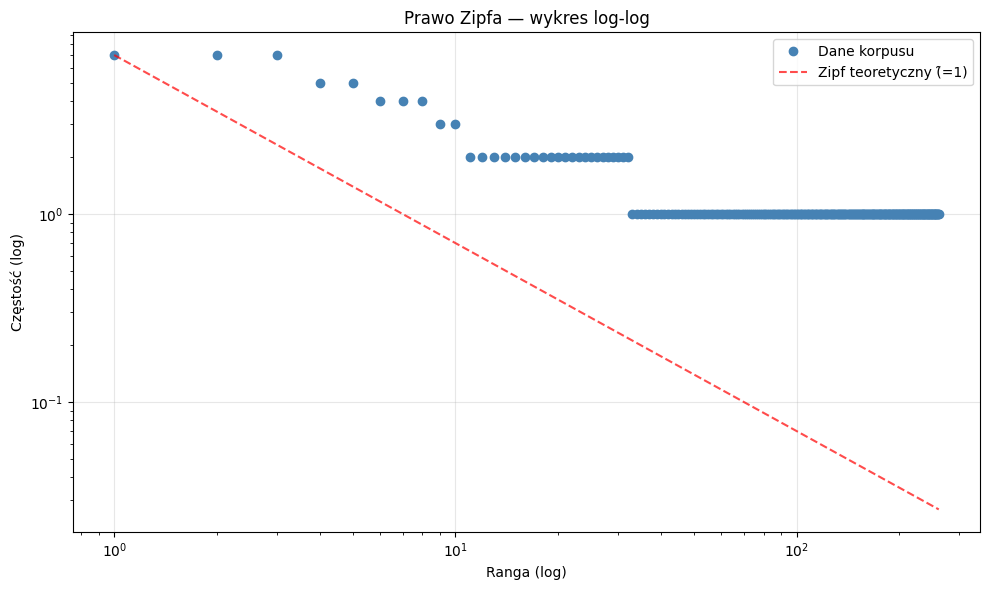

In [26]:
# Wykres log-log prawa Zipfa
ranks = range(1, len(freq) + 1)
frequencies = sorted(freq.values(), reverse=True)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, frequencies, marker="o", linestyle="none", color="steelblue", label="Dane korpusu")
plt.xlabel("Ranga (log)")
plt.ylabel("Częstość (log)")
plt.title("Prawo Zipfa — wykres log-log")
plt.grid(True, alpha=0.3)

# Linia teoretyczna
C = frequencies[0]
zipf_theoretical = [C / r for r in ranks]
plt.loglog(ranks, zipf_theoretical, "--", color="red", label="Zipf teoretyczny (̑=1)", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Pokrycie top-N sł3w
total_word_count = sum(freq.values())
top10 = freq.most_common(10)
coverage10 = sum(c for _, c in top10) / total_word_count
print(f"Top 10 słow pokrywa {coverage10*100:.1f}% wszystkich tokenow w korpusie.")

Top 10 sł3w pokrywa 15.2% wszystkich token3w w korpusie.


---
## 12. Zadania dodatkowe

Poniżej kilka dodatkowych zadań do samodzielnego rozwiązania:

### Zadanie A: Porównanie zbiorów
Załaduj **dwa różne** pliki CSV (np. `recenzje_filmowe.csv` i `recenzje_restauracji.csv`). Porównaj:
- Średnią długość dokumentu
- TTR korpusu
- Liczbę hapax legomena
- Top 10 słów (bez stop words)

### Zadanie B: Analiza sentymentu — różnice słownikowe
Dla zbioru `recenzje_filmowe.csv`:
1. Podziel recenzje na pozytywne i negatywne.
2. Dla każdej grupy oblicz top 20 słów (bez stop words).
3. Które słowa występują **tylko** w recenzjach pozytywnych? A które **tylko** w negatywnych?

### Zadanie C: Strefy Zipfa (Luhn)
Na podstawie wykresu Zipfa z zadania 11:
1. Zidentyfikuj **górną strefę** (stop words — zbyt częste).
2. Zidentyfikuj **dolną strefę** (hapax legomena — zbyt rzadkie).
3. Wypisz słowa ze **środkowej strefy** — potencjalnie najcenniejsze informacyjnie.

In [28]:
def get_corpus_stats(file_path, name):
    temp_df = pd.read_csv(file_path)
    # Tokenizacja
    temp_df['tokens'] = temp_df['text'].apply(lambda x: word_tokenize(x, language='polish'))
    all_t = [t.lower() for sublist in temp_df['tokens'] for t in sublist if t.isalpha() and len(t) > 1]

    # Metryki
    avg_len = np.mean(temp_df['tokens'].apply(len))
    ttr = len(set(all_t)) / len(all_t) if len(all_t) > 0 else 0
    freqs = Counter(all_t)
    hapax_count = len([w for w, c in freqs.items() if c == 1])
    top_10 = [w for w, c in Counter([w for w in all_t if w not in stop_pl]).most_common(10)]

    return {
        'Zbiór': name,
        'Śr. dł. dok.': round(avg_len, 2),
        'TTR': round(ttr, 4),
        'Hapaxy': hapax_count,
        'Top 10 słów': ", ".join(top_10)
    }

# Porównanie
stats_film = get_corpus_stats('recenzje_filmowe.csv', 'Filmy')
stats_rest = get_corpus_stats('recenzje_restauracji.csv', 'Restauracje')

comparison_df = pd.DataFrame([stats_film, stats_rest])
display(comparison_df)

,Zbiór,Śr. dł. dok.,TTR,Hapaxy,Top 10 słów
0,Filmy,18.55,0.7369,343,"film, reżyser, aktorzy, kino, fabuła, scenariu..."
1,Restauracje,21.90,0.8106,229,"złotych, porcje, ciasto, świeże, najlepsza, ob..."


In [30]:
# Zadanie B: Analiza sentymentu w recenzjach filmowych
df_film = pd.read_csv('recenzje_filmowe.csv')

def get_filtered_tokens(text):
    tokens = word_tokenize(text, language='polish')
    return [t.lower() for t in tokens if t.isalpha() and len(t) > 1 and t.lower() not in stop_pl]

# Podział na grupy - poprawiona nazwa kolumny na 'label'
pos_reviews = df_film[df_film['label'] == 'pozytywna']['text']
neg_reviews = df_film[df_film['label'] == 'negatywna']['text']

pos_tokens = [t for text in pos_reviews for t in get_filtered_tokens(text)]
neg_tokens = [t for text in neg_reviews for t in get_filtered_tokens(text)]

pos_freq = Counter(pos_tokens)
neg_freq = Counter(neg_tokens)

# Słowa unikalne dla każdej grupy
only_pos = set(pos_freq.keys()) - set(neg_freq.keys())
only_neg = set(neg_freq.keys()) - set(pos_freq.keys())

print("Top 20 słów w pozytywnych:", [w for w, c in pos_freq.most_common(20)])
print("Top 20 słów w negatywnych:", [w for w, c in neg_freq.most_common(20)])
print("\nPrzykładowe słowa TYLKO w pozytywnych:", list(only_pos)[:10])
print("Przykładowe słowa TYLKO w negatywnych:", list(only_neg)[:10])

Top 20 słów w pozytywnych: ['film', 'kino', 'aktorzy', 'sceny', 'gra', 'poziomie', 'widza', 'muzyka', 'ekranie', 'dobry', 'dzieci', 'piękne', 'naprawdę', 'przesłaniem', 'genialny', 'siebie', 'fenomenalny', 'akcji', 'najlepszym', 'wydaniu']
Top 20 słów w negatywnych: ['film', 'reżyser', 'niestety', 'fabuła', 'kompletna', 'strata', 'scenariusz', 'filmu', 'miał', 'zbyt', 'pretensjonalny', 'godzinę', 'najgorszych', 'filmów', 'widziałem', 'nudna', 'przewidywalna', 'aktorzy', 'grali', 'przekonania']

Przykładowe słowa TYLKO w pozytywnych: ['poruszający', 'tematy', 'wspaniały', 'fantastyczna', 'najwyższym', 'niezwykły', 'książki', 'thriller', 'scena', 'aktorska']
Przykładowe słowa TYLKO w negatywnych: ['bilet', 'kompletnie', 'beznadziejny', 'ciekawego', 'długi', 'zasypiała', 'dostaliśmy', 'trzyma', 'dziewięćdziesiątych', 'napisami']


In [31]:
# Zadanie C: Strefy Zipfa (Luhn)
# Wykorzystujemy obliczone wcześniej częstości (zmienna freq)
sorted_freq = freq.most_common()

# 1. Górna strefa (najczęstsze słowa, ranga 1-10)
upper_zone = sorted_freq[:10]

# 2. Dolna strefa (hapax legomena - częstość 1)
lower_zone = [w for w, c in sorted_freq if c == 1]

# 3. Środkowa strefa (znaczące - ranga > 10 i częstość > 1)
middle_zone = [w for w, c in sorted_freq[10:] if c > 1]

print("--- GÓRNA STREFA (Zbyt częste / Stop words) ---")
print([w for w, c in upper_zone])

print("\n--- ŚRODKOWA STREFA (Najcenniejsze informacyjnie) ---")
print(middle_zone)

print("\n--- DOLNA STREFA (Zbyt rzadkie / Hapaxy - pierwsze 20) ---")
print(lower_zone[:20])

--- GÓRNA STREFA (Zbyt częste / Stop words) ---
['na', 'za', 'jak', 'złotych', 'to', 'nie', 'porcje', 'do', 'ciasto', 'świeże']

--- ŚRODKOWA STREFA (Najcenniejsze informacyjnie) ---
['najlepsza', 'obsługa', 'dnia', 'bez', 'smaku', 'przyszło', 'po', 'kelner', 'proszku', 'tego', 'dwadzieścia', 'mięso', 'frytki', 'kawa', 'godziny', 'kuchnia', 'ceny', 'od', 'jedzenie', 'jest', 'pyszne', 'czterdzieści']

--- DOLNA STREFA (Zbyt rzadkie / Hapaxy - pierwsze 20) ---
['pizza', 'mieście', 'cienkie', 'chrupiące', 'składniki', 'sos', 'pomidorowy', 'domowej', 'roboty', 'miła', 'szybka', 'pewno', 'wrócę', 'zupa', 'była', 'letnia', 'drugie', 'danie', 'czterdziestu', 'minutach']
